In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load the feature dataset from Week 3
df = pd.read_csv(
    'data/processed/AAPL_features.csv',
    index_col='Date',
    parse_dates=True
)

print('Shape:', df.shape)
print()
print(df.head())


Shape: (452, 11)

            Daily_Return         MA5  MA5_to_MA20  Price_to_MA20  Lag1_Return  \
Date                                                                            
2024-09-04     -0.008619  224.100089     1.011514       0.989427    -0.027205   
2024-09-05      0.006928  223.284207     1.004949       0.993432    -0.008619   
2024-09-06     -0.007015  221.503555     0.995210       0.984757     0.006928   
2024-09-09      0.000408  219.897595     0.986912       0.984079    -0.007015   
2024-09-10     -0.003622  219.369547     0.983977       0.979952     0.000408   

            Lag2_Return  Volatility_5d  Volume_Change     RSI_14  \
Date                                                               
2024-09-04    -0.003438       0.014886      -0.126526  48.215029   
2024-09-05    -0.027205       0.015995      -0.164799  44.890861   
2024-09-06    -0.008619       0.012387       0.322476  38.694382   
2024-09-09     0.006928       0.012842       0.387357  39.202144   
2024-0

In [70]:
# Define our features and target — same list from Week 3
feature_cols = [
    'Daily_Return',
    'MA5',
    'MA5_to_MA20',
    'Price_to_MA20',
    'Lag1_Return',
    'Lag2_Return',
    'Volatility_5d',
    'Volume_Change',
    'RSI_14',
    'Close_to_MA50'
]

X = df[feature_cols]   # features — the inputs
y = df['Target']       # target  — what we predict

print('X shape:', X.shape)
print('y shape:', y.shape)
print()
print('Target distribution:')
print(y.value_counts())
print(y.value_counts(normalize=True).round(3))


X shape: (452, 10)
y shape: (452,)

Target distribution:
Target
1    241
0    211
Name: count, dtype: int64
Target
1    0.533
0    0.467
Name: proportion, dtype: float64


In [71]:
# We split 80% for training, 20% for testing
# The split must respect time order — no shuffling

split_index = int(len(X) * 0.8)

X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]

print(f'Training rows : {len(X_train)}')
print(f'Test rows     : {len(X_test)}')
print()
print(f'Training period: {X_train.index[0].date()} to {X_train.index[-1].date()}')
print(f'Test period    : {X_test.index[0].date()}  to {X_test.index[-1].date()}')


Training rows : 361
Test rows     : 91

Training period: 2024-09-04 to 2026-02-11
Test period    : 2026-02-12  to 2026-06-24


In [73]:
# Step 3: Make predictions on the test set
lr_predictions = lr_model.predict(X_test)

# Peek at the first 10 predictions vs the real answers
comparison = pd.DataFrame({
    'Actual':     y_test.values[:10],
    'Predicted':  lr_predictions[:10]
}, index=y_test.index[:10])

print('First 10 predictions vs actual:')
print(comparison)


First 10 predictions vs actual:
            Actual  Predicted
Date                         
2026-02-12       0          0
2026-02-13       1          0
2026-02-17       1          0
2026-02-18       0          0
2026-02-19       1          0
2026-02-20       1          0
2026-02-23       1          0
2026-02-24       1          0
2026-02-25       0          0
2026-02-26       0          0


In [74]:
# Step 4: Evaluate accuracy
from sklearn.metrics import accuracy_score

lr_accuracy = accuracy_score(y_test, lr_predictions)
print(f'Logistic Regression Accuracy: {lr_accuracy:.2%}')

# Also check training accuracy (useful for detecting overfitting later)
lr_train_accuracy = accuracy_score(y_train, lr_model.predict(X_train))
print(f'Training Accuracy           : {lr_train_accuracy:.2%}')


Logistic Regression Accuracy: 48.35%
Training Accuracy           : 52.91%


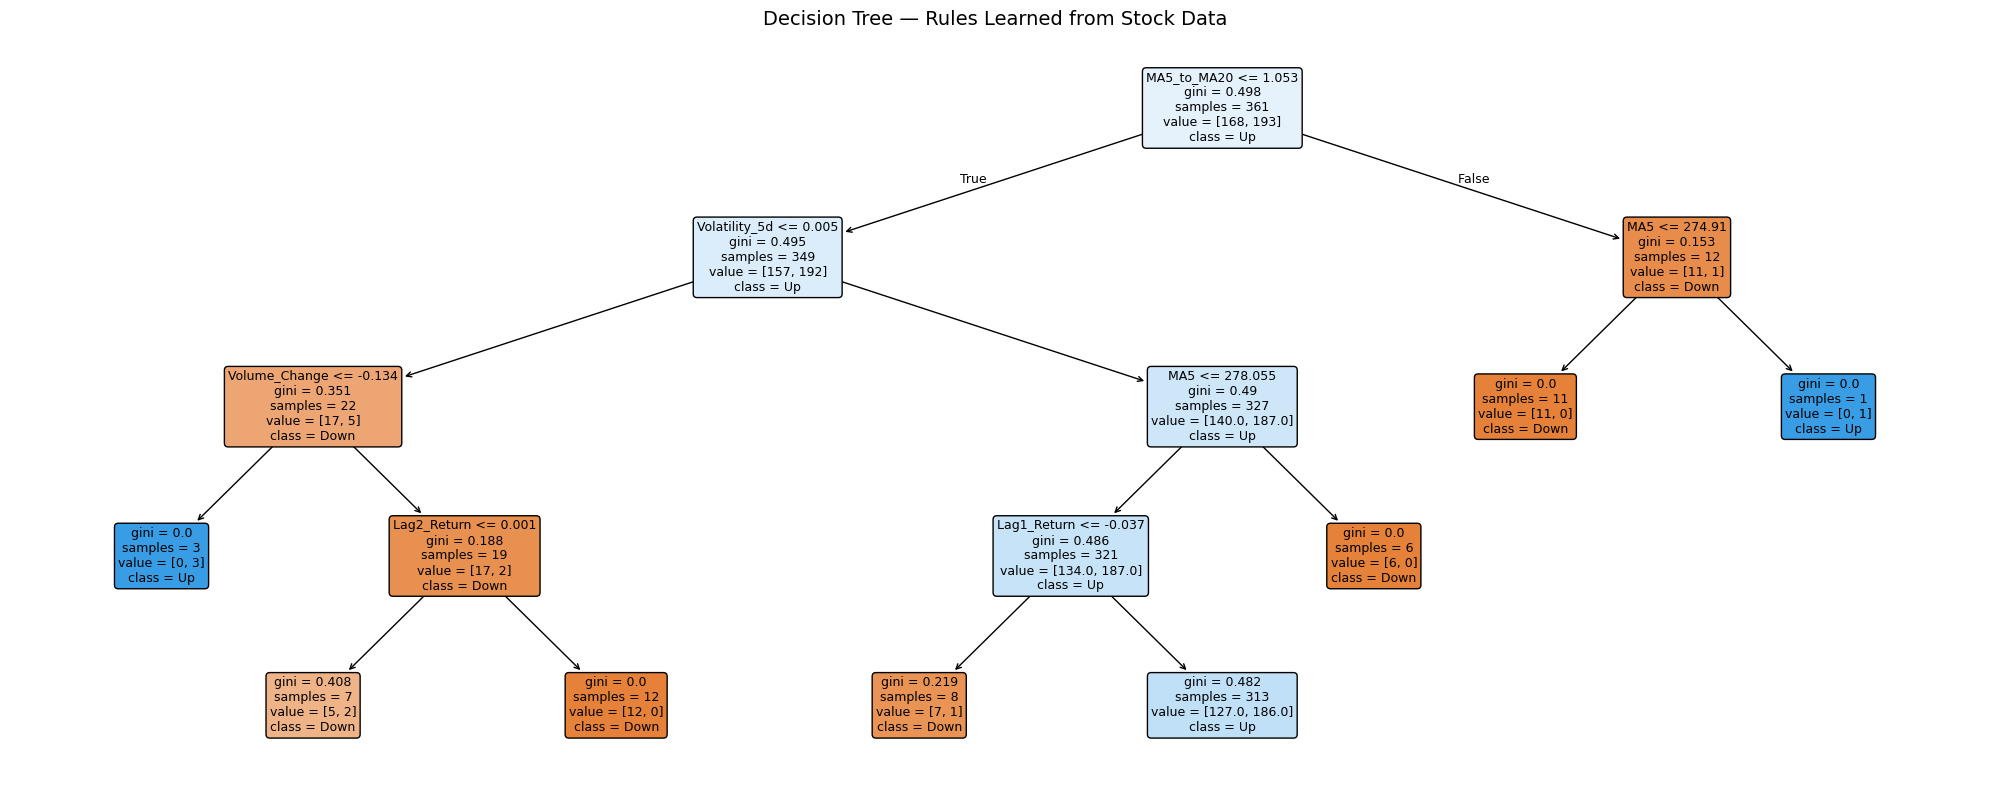

In [76]:
# Visualize the Decision Tree — see the rules it learned
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 8))
plot_tree(
    dt_model,
    feature_names=feature_cols,
    class_names=['Down', 'Up'],
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title('Decision Tree — Rules Learned from Stock Data', fontsize=14)
plt.tight_layout()
plt.show()


In [77]:
'''The first split is on MA5_to_MA20 — whether the 5-day average is above or below ~1.05x the 20-day average. This makes intuitive sense: it's effectively checking short-term momentum relative to the medium-term trend, which is exactly the kind of signal traders watch for (similar to a Golden/Death Cross). Notably, RSI_14 and Close_to_MA50 never get used anywhere in the tree — they had zero feature importance, suggesting the momentum information they capture was already redundant with MA5_to_MA20.'''

"The first split is on MA5_to_MA20 — whether the 5-day average is above or below ~1.05x the 20-day average. This makes intuitive sense: it's effectively checking short-term momentum relative to the medium-term trend, which is exactly the kind of signal traders watch for (similar to a Golden/Death Cross). Notably, RSI_14 and Close_to_MA50 never get used anywhere in the tree — they had zero feature importance, suggesting the momentum information they capture was already redundant with MA5_to_MA20."

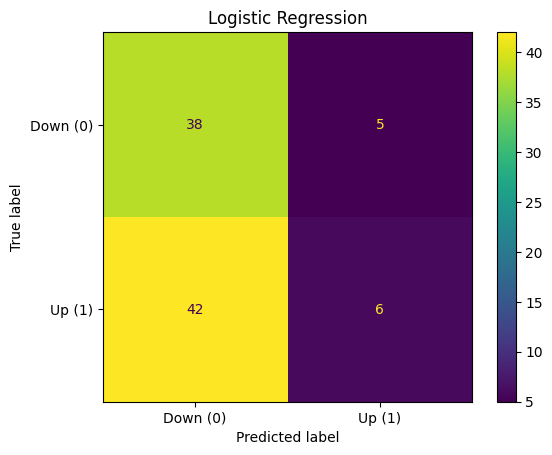

In [78]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, lr_predictions)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Down (0)', 'Up (1)']
).plot()

plt.title("Logistic Regression")
plt.show()


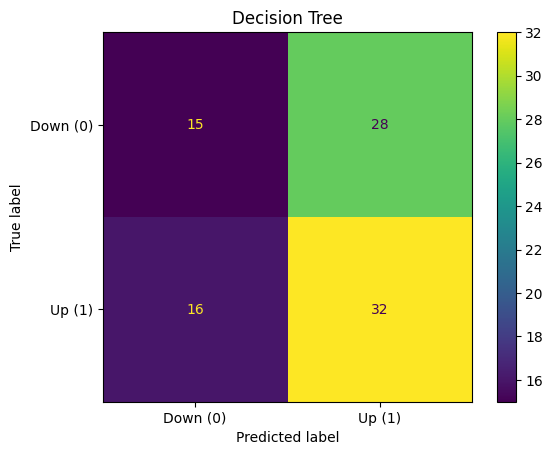

In [79]:
cm = confusion_matrix(y_test, dt_predictions)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Down (0)', 'Up (1)']
).plot()

plt.title("Decision Tree")
plt.show()

In [80]:
from sklearn.metrics import precision_score, recall_score

print('=== Logistic Regression ===')

print("Precision:", precision_score(y_test, lr_predictions))
print("Recall:", recall_score(y_test, lr_predictions))

print('=== Decision Tree ===')
print("Precision:", precision_score(y_test, dt_predictions))
print("Recall:", recall_score(y_test, dt_predictions))


=== Logistic Regression ===
Precision: 0.5454545454545454
Recall: 0.125
=== Decision Tree ===
Precision: 0.5333333333333333
Recall: 0.6666666666666666


                     Train Accuracy  Test Accuracy
Logistic Regression           52.91          48.35
Decision Tree                 63.99          51.65


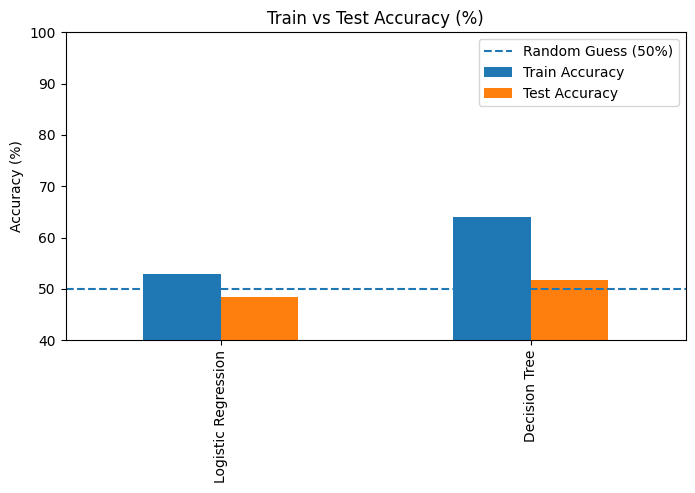

In [81]:
# Side-by-side comparison of both models
results = pd.DataFrame({
    'Train Accuracy': [lr_train_accuracy * 100,
                       dt_train_accuracy * 100],
    'Test Accuracy': [lr_accuracy * 100,
                      dt_accuracy * 100]
}, index=['Logistic Regression', 'Decision Tree'])

print(results.round(2))

results.plot(kind='bar', figsize=(8, 4))

plt.axhline(50, linestyle='--',
            label='Random Guess (50%)')

plt.ylabel("Accuracy (%)")
plt.title("Train vs Test Accuracy (%)")
plt.ylim(40, 100)

plt.legend()
plt.show()

In [82]:
# A tree with no depth limit will grow until every training row is perfectly classified
dt_overfit = DecisionTreeClassifier(max_depth=None, random_state=42)
dt_overfit.fit(X_train, y_train)

overfit_train_acc = accuracy_score(y_train, dt_overfit.predict(X_train))
overfit_test_acc  = accuracy_score(y_test,  dt_overfit.predict(X_test))

print(f'Unlimited Tree — Train Accuracy: {overfit_train_acc:.2%}')
print(f'Unlimited Tree — Test Accuracy : {overfit_test_acc:.2%}')
print()
print('Compare to our max_depth=4 tree:')
print(f'Depth-4 Tree  — Train Accuracy: {dt_train_accuracy:.2%}')
print(f'Depth-4 Tree  — Test Accuracy : {dt_accuracy:.2%}')


Unlimited Tree — Train Accuracy: 100.00%
Unlimited Tree — Test Accuracy : 43.96%

Compare to our max_depth=4 tree:
Depth-4 Tree  — Train Accuracy: 63.99%
Depth-4 Tree  — Test Accuracy : 51.65%


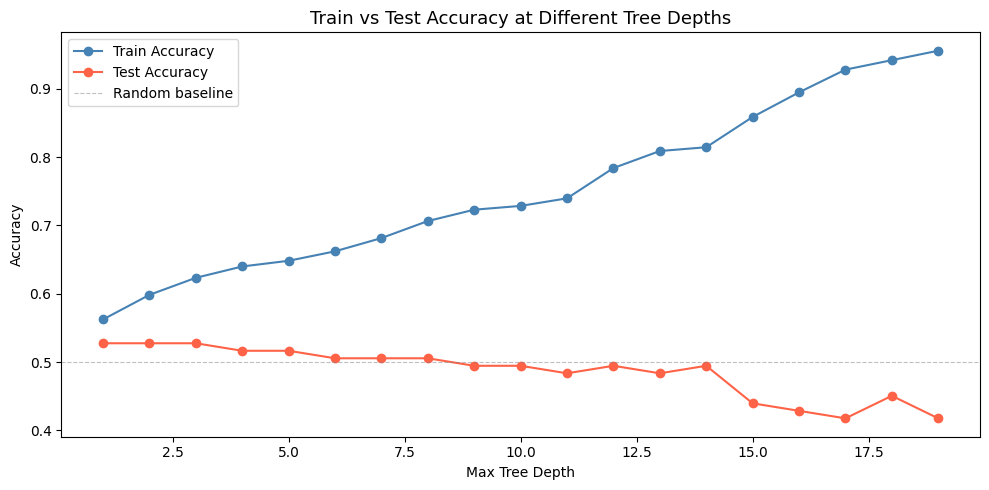

In [83]:
# How does test accuracy change as we increase tree depth?
depths = range(1, 20)
train_scores = []
test_scores  = []

for depth in depths:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, model.predict(X_train)))
    test_scores.append(accuracy_score(y_test,  model.predict(X_test)))

plt.figure(figsize=(10, 5))
plt.plot(depths, train_scores, label='Train Accuracy', marker='o', color='steelblue')
plt.plot(depths, test_scores,  label='Test Accuracy',  marker='o', color='tomato')
plt.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.5, label='Random baseline')
plt.xlabel('Max Tree Depth')
plt.ylabel('Accuracy')
plt.title('Train vs Test Accuracy at Different Tree Depths', fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()


In [84]:
importances = pd.Series(dt_model.feature_importances_, index=feature_cols)

print(importances.sort_values(ascending=False).round(4))


MA5              0.2421
MA5_to_MA20      0.2099
Volatility_5d    0.2032
Volume_Change    0.1722
Lag1_Return      0.1426
Lag2_Return      0.0300
Daily_Return     0.0000
Price_to_MA20    0.0000
RSI_14           0.0000
Close_to_MA50    0.0000
dtype: float64


In [85]:
summary = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree (depth=4)', 'Decision Tree (unlimited — overfit)'],
    'Train Acc': [f'{lr_train_accuracy:.1%}', f'{dt_train_accuracy:.1%}', f'{overfit_train_acc:.1%}'],
    'Test Acc':  [f'{lr_accuracy:.1%}',       f'{dt_accuracy:.1%}',       f'{overfit_test_acc:.1%}'],
})
print(summary.to_string(index=False))


                              Model Train Acc Test Acc
                Logistic Regression     52.9%    48.4%
            Decision Tree (depth=4)     64.0%    51.6%
Decision Tree (unlimited — overfit)    100.0%    44.0%


## Week 4 Assignment

Choose a stock other than AAPL.

1. Load the stock's dataset.
2. Add the custom feature you created in Week 3.
3. Train both Logistic Regression and Decision Tree models.
4. Evaluate both models using:
   - Train accuracy
   - Test accuracy
   - Confusion matrix
5. Compare the results to AAPL.

Document 
- Your accuracy results
- The confusion matrices
- A short conclusion on which model and stock performed better.

In [87]:
import yfinance as yf

In [88]:

df_rel = yf.download("RELIANCE.NS", period="2y")

if isinstance(df_rel.columns, pd.MultiIndex):
    df_rel.columns = df_rel.columns.get_level_values(0)

print(df_rel.shape)
print(df_rel.head())

[*********************100%***********************]  1 of 1 completed

(499, 5)
Price             Close         High          Low         Open    Volume
Date                                                                    
2024-06-25  1436.822998  1438.576872  1423.829664  1425.805833   7045386
2024-06-26  1495.984497  1500.875467  1427.905458  1428.819485  22014882
2024-06-27  1512.312622  1519.179760  1488.055102  1495.712756  28383030
2024-06-28  1546.747437  1562.161530  1512.782033  1512.782033  28957336
2024-07-01  1541.559937  1560.580562  1537.138283  1543.906637   7724306


In [89]:


df_rel["Daily_Return"] = df_rel["Close"].pct_change()
df_rel["MA5"] = df_rel["Close"].rolling(window=5).mean()
df_rel["MA20"] = df_rel["Close"].rolling(window=20).mean()
df_rel["MA50"] = df_rel["Close"].rolling(window=50).mean()

df_rel["MA5_to_MA20"] = df_rel["MA5"] / df_rel["MA20"]
df_rel["Price_to_MA20"] = df_rel["Close"] / df_rel["MA20"]
df_rel["Lag1_Return"] = df_rel["Daily_Return"].shift(1)
df_rel["Lag2_Return"] = df_rel["Daily_Return"].shift(2)
df_rel["Volatility_5d"] = df_rel["Daily_Return"].rolling(window=5).std()
df_rel["Volume_Change"] = df_rel["Volume"].pct_change()

# Your custom features from Week 3
delta = df_rel["Close"].diff()
gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)
avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()
rs = avg_gain / avg_loss
df_rel["RSI_14"] = 100 - (100 / (1 + rs))

df_rel["Close_to_MA50"] = df_rel["Close"] / df_rel["MA50"]

# Target — same logic as before
df_rel["Target"] = (df_rel["Close"].shift(-1) > df_rel["Close"]).astype(int)

print(df_rel[feature_cols + ["Target"]].dropna().shape)

(450, 11)


In [90]:
df_rel_ml = df_rel[feature_cols + ["Target"]].dropna()

X_rel = df_rel_ml[feature_cols]
y_rel = df_rel_ml["Target"]

split_index_rel = int(len(X_rel) * 0.8)

X_rel_train = X_rel.iloc[:split_index_rel]
X_rel_test  = X_rel.iloc[split_index_rel:]
y_rel_train = y_rel.iloc[:split_index_rel]
y_rel_test  = y_rel.iloc[split_index_rel:]

print(f"Training rows: {len(X_rel_train)}")
print(f"Test rows: {len(X_rel_test)}")

Training rows: 360
Test rows: 90


In [91]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Logistic Regression
lr_rel_model = LogisticRegression(max_iter=1000, random_state=42)
lr_rel_model.fit(X_rel_train, y_rel_train)
lr_rel_predictions = lr_rel_model.predict(X_rel_test)

lr_rel_accuracy = accuracy_score(y_rel_test, lr_rel_predictions)
lr_rel_train_accuracy = accuracy_score(y_rel_train, lr_rel_model.predict(X_rel_train))

print(f"Logistic Regression — Train: {lr_rel_train_accuracy:.2%} | Test: {lr_rel_accuracy:.2%}")

# Decision Tree
dt_rel_model = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_rel_model.fit(X_rel_train, y_rel_train)
dt_rel_predictions = dt_rel_model.predict(X_rel_test)

dt_rel_accuracy = accuracy_score(y_rel_test, dt_rel_predictions)
dt_rel_train_accuracy = accuracy_score(y_rel_train, dt_rel_model.predict(X_rel_train))

print(f"Decision Tree — Train: {dt_rel_train_accuracy:.2%} | Test: {dt_rel_accuracy:.2%}")

ValueError: Input X contains infinity or a value too large for dtype('float64').

In [92]:
import numpy as np

for col in feature_cols:
    inf_count = np.isinf(df_rel_ml[col]).sum()
    if inf_count > 0:
        print(f"{col}: {inf_count} infinite values")

Volume_Change: 4 infinite values


In [93]:
import numpy as np

df_rel_ml = df_rel_ml.replace([np.inf, -np.inf], np.nan).dropna()

print("Shape after removing infinities:", df_rel_ml.shape)

Shape after removing infinities: (446, 11)


In [94]:
X_rel = df_rel_ml[feature_cols]
y_rel = df_rel_ml["Target"]

split_index_rel = int(len(X_rel) * 0.8)

X_rel_train = X_rel.iloc[:split_index_rel]
X_rel_test  = X_rel.iloc[split_index_rel:]
y_rel_train = y_rel.iloc[:split_index_rel]
y_rel_test  = y_rel.iloc[split_index_rel:]

print(f"Training rows: {len(X_rel_train)}")
print(f"Test rows: {len(X_rel_test)}")

Training rows: 356
Test rows: 90


In [95]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

lr_rel_model = LogisticRegression(max_iter=1000, random_state=42)
lr_rel_model.fit(X_rel_train, y_rel_train)
lr_rel_predictions = lr_rel_model.predict(X_rel_test)

lr_rel_accuracy = accuracy_score(y_rel_test, lr_rel_predictions)
lr_rel_train_accuracy = accuracy_score(y_rel_train, lr_rel_model.predict(X_rel_train))

print(f"Logistic Regression — Train: {lr_rel_train_accuracy:.2%} | Test: {lr_rel_accuracy:.2%}")

dt_rel_model = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_rel_model.fit(X_rel_train, y_rel_train)
dt_rel_predictions = dt_rel_model.predict(X_rel_test)

dt_rel_accuracy = accuracy_score(y_rel_test, dt_rel_predictions)
dt_rel_train_accuracy = accuracy_score(y_rel_train, dt_rel_model.predict(X_rel_train))

print(f"Decision Tree — Train: {dt_rel_train_accuracy:.2%} | Test: {dt_rel_accuracy:.2%}")

Logistic Regression — Train: 60.11% | Test: 57.78%
Decision Tree — Train: 68.54% | Test: 47.78%


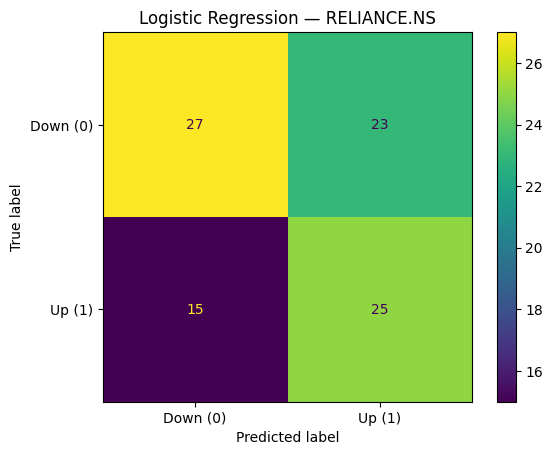

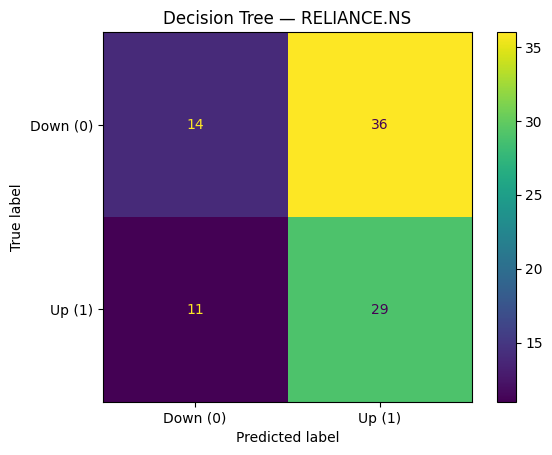

In [96]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_lr_rel = confusion_matrix(y_rel_test, lr_rel_predictions)
ConfusionMatrixDisplay(confusion_matrix=cm_lr_rel, display_labels=['Down (0)', 'Up (1)']).plot()
plt.title("Logistic Regression — RELIANCE.NS")
plt.show()

cm_dt_rel = confusion_matrix(y_rel_test, dt_rel_predictions)
ConfusionMatrixDisplay(confusion_matrix=cm_dt_rel, display_labels=['Down (0)', 'Up (1)']).plot()
plt.title("Decision Tree — RELIANCE.NS")
plt.show()